# Oficina de IA

## 1 - Identificação dos integrantes, origem da base e pergunta do projeto.

* Leandro Lima Cardoso (202323366)
* João Vitor Afonso Damascena (202312489)
*  ()
* Almir Coelho Rubim Junior (202312480)

## Preparacão

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

## 2 - Resultados de head, shape, info e describe interpretados.

In [38]:
df = pd.read_csv("dataset_desempenho_academicO.csv", sep=',', encoding='utf-8')
espaco = '\n' * 2

display("Mostra as cinco primeiras linhas:", df.head())
print(espaco)
display("Linhas e colunas:", df.shape)
print(espaco)
display("Tipos das colunas e contagem de valores não ausentes:", df.info())
print(espaco)
display("Resumo estatístico das colunas:", df.describe(include="all"))


'Mostra as cinco primeiras linhas:'

,id_registro,curso,periodo,modalidade,turno,horas_estudo_semanais,frequencia_percentual,atividades_entregues_percentual,nota_diagnostica,acessos_ava_semanais,horas_trabalho_semanais,tempo_deslocamento_minutos,aprovado
0,7690,Engenharia de Software,8,Presencial,Manha,NaN,78.9,68.3,9.3,5.0,20,90.0,Sim
1,4544,Administracao,6,Hibrida,Manha,6.3,81.4,74.8,5.7,7.0,40,15.0,Nao
2,8940,Engenharia Civil,5,EAD,Manha,5.8,75.2,67.7,4.3,5.0,44,0.0,Nao
3,8416,Enfermagem,5,Hibrida,Noite,2.1,75.6,93.9,7.1,2.0,30,30.0,Nao
4,9909,Administracao,3,Presencial,Noite,6.9,92.7,82.8,5.4,12.0,0,45.0,Sim


'Linhas e colunas:'

(10000, 13)




<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_registro                      10000 non-null  int64  
 1   curso                            10000 non-null  str    
 2   periodo                          10000 non-null  int64  
 3   modalidade                       10000 non-null  str    
 4   turno                            10000 non-null  str    
 5   horas_estudo_semanais            9769 non-null   float64
 6   frequencia_percentual            10000 non-null  float64
 7   atividades_entregues_percentual  9799 non-null   float64
 8   nota_diagnostica                 9835 non-null   float64
 9   acessos_ava_semanais             9909 non-null   float64
 10  horas_trabalho_semanais          10000 non-null  int64  
 11  tempo_deslocamento_minutos       9788 non-null   float64
 12  aprovado                   

'Tipos das colunas e contagem de valores não ausentes:'

None

'Resumo estatístico das colunas:'

,id_registro,curso,periodo,modalidade,turno,horas_estudo_semanais,frequencia_percentual,atividades_entregues_percentual,nota_diagnostica,acessos_ava_semanais,horas_trabalho_semanais,tempo_deslocamento_minutos,aprovado
count,10000.000000,10000,10000.000000,10000,10000,9769.000000,10000.000000,9799.000000,9835.000000,9909.000000,10000.000000,9788.000000,10000
unique,NaN,5,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,Administracao,NaN,Presencial,Noite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nao
freq,NaN,2095,NaN,5519,5008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5586
mean,4976.321500,NaN,4.497300,NaN,NaN,6.755983,82.991600,74.896449,6.044118,5.952972,22.360600,41.692889,NaN
std,2872.565848,NaN,2.281954,NaN,NaN,3.513540,10.437332,16.879208,1.770919,3.353667,17.485495,38.269370,NaN
min,1.000000,NaN,1.000000,NaN,NaN,0.200000,35.500000,8.200000,0.000000,0.000000,0.000000,0.000000,NaN
25%,2490.750000,NaN,3.000000,NaN,NaN,4.200000,75.800000,63.400000,4.900000,4.000000,0.000000,10.000000,NaN
50%,4977.500000,NaN,4.000000,NaN,NaN,6.700000,83.400000,75.800000,6.000000,6.000000,30.000000,30.000000,NaN
75%,7463.250000,NaN,6.000000,NaN,NaN,9.100000,90.800000,87.900000,7.300000,8.000000,40.000000,60.000000,NaN


## 3 - Diagnóstico de ausências e duplicatas.

In [39]:
ausencias_qtd = df.isna().sum()
ausencias_pct = df.isna().mean().mul(100).round(2)
df_ausencias = pd.DataFrame({"Ausentes (Qtd)": ausencias_qtd, "Ausentes (%)": ausencias_pct})
display(df_ausencias[df_ausencias["Ausentes (Qtd)"] > 0].sort_values(by="Ausentes (Qtd)", ascending=False))

linhas_duplicadas = df.duplicated().sum()
print(f"\nQuantidade de linhas duplicadas: {linhas_duplicadas}")

,Ausentes (Qtd),Ausentes (%)
horas_estudo_semanais,231,2.31
tempo_deslocamento_minutos,212,2.12
atividades_entregues_percentual,201,2.01
nota_diagnostica,165,1.65
acessos_ava_semanais,91,0.91



Quantidade de linhas duplicadas: 50


## 4 - Dois gráficos acompanhados de interpretação.

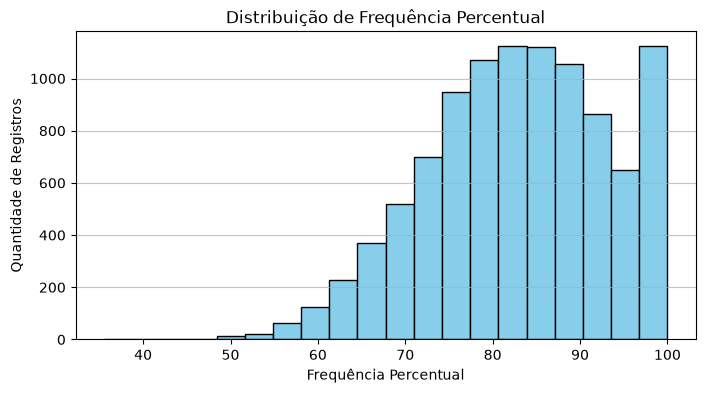

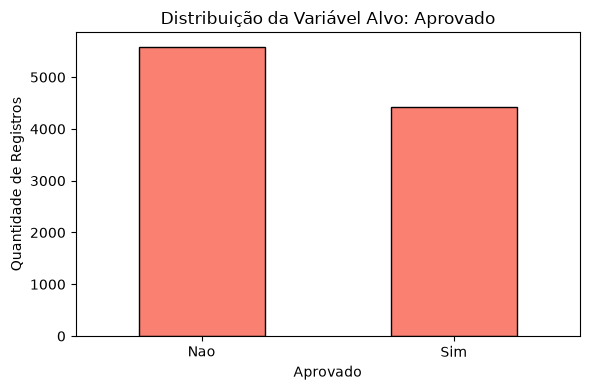

In [41]:
plt.figure(figsize=(8, 4))
df["frequencia_percentual"].dropna().plot.hist(
    bins=20, color="skyblue", edgecolor="black"
)
plt.title("Distribuição de Frequência Percentual")
plt.xlabel("Frequência Percentual")
plt.ylabel("Quantidade de Registros")
plt.grid(axis="y", alpha=0.75)
plt.show()

plt.figure(figsize=(6, 4))
df["aprovado"].value_counts().plot.bar(color="salmon", edgecolor="black")
plt.title("Distribuição da Variável Alvo: Aprovado")
plt.xlabel("Aprovado")
plt.ylabel("Quantidade de Registros")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5 - Registro das alterações feitas e suas justificativas.

In [52]:
df_trabalho = df.copy()
antes_duplicadas = len(df_trabalho)
df_trabalho = df_trabalho.drop_duplicates()
removidas_duplicadas = antes_duplicadas - len(df_trabalho)
print(f"1. Linhas duplicadas removidas: {removidas_duplicadas}")
print(
    "Justificativa: Eram registos redundantes decorrentes de erros técnicos de exportação."
)

colunas_para_imputar = [
    "horas_estudo_semanais",
    "atividades_entregues_percentual",
    "nota_diagnostica",
    "acessos_ava_semanais",
    "tempo_deslocamento_minutos",
]
print(f"\n\n2. Imputações nas colunas:")
for coluna in colunas_para_imputar:
    nulos_antes = df_trabalho[coluna].isna().sum()
    if nulos_antes > 0:
        mediana_valor = df_trabalho[coluna].median()
        df_trabalho[coluna].fillna(mediana_valor, inplace=True)
        print(f"- {coluna}: {nulos_antes} nulos de mediana ({mediana_valor}).")

print("Justificativa: Evita a perda total de registos importantes (drop de linhas) e impede distorções causadas pelo uso da média em dados assimétricos.")

if "id_registro" in df_trabalho.columns:
    df_trabalho = df_trabalho.drop(columns=["id_registro"])
    print("\n\n3. Coluna excluída: 'id_registro'")
    print(
        "Justificativa: Trata-se de um identificador unívoco aleatório que não traz nenhuma informação lógica ou padrão preditivo para o modelo de machine learning."
)

print(f"\n\nTamanho final do dataset de trabalho: {df_trabalho.shape}")

1. Linhas duplicadas removidas: 50
Justificativa: Eram registos redundantes decorrentes de erros técnicos de exportação.


2. Imputações nas colunas:
- horas_estudo_semanais: 230 nulos de mediana (6.7).
- atividades_entregues_percentual: 201 nulos de mediana (75.7).
- nota_diagnostica: 164 nulos de mediana (6.0).
- acessos_ava_semanais: 91 nulos de mediana (6.0).
- tempo_deslocamento_minutos: 212 nulos de mediana (30.0).
Justificativa: Evita a perda total de registos importantes (drop de linhas) e impede distorções causadas pelo uso da média em dados assimétricos.


3. Coluna excluída: 'id_registro'
Justificativa: Trata-se de um identificador unívoco aleatório que não traz nenhuma informação lógica ou padrão preditivo para o modelo de machine learning.


Tamanho final do dataset de trabalho: (9950, 12)


/tmp/ipykernel_11398/2472579285.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_trabalho[coluna].fillna(mediana_valor, inplace=True)
/tmp/ipykernel_11398/2472579285.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method nev

## 6 - Definição de features e target, quando aplicável.

In [53]:
configuracao = {
    "Tarefa": "Classificação Binária",
    "Target": "aprovado",
    "Features": [
        "curso",
        "periodo",
        "modalidade",
        "turno",
        "horas_estudo_semanais",
        "frequencia_percentual",
        "atividades_entregues_percentual",
        "nota_diagnostica",
        "acessos_ava_semanais",
        "horas_trabalho_semanais",
        "tempo_deslocamento_minutos",
    ],
    "Colunas Excluídas": ["id_registro"],
    "Justificativa Exclusão": "Identificador unívoco sem poder preditivo.",
}
for k, v in configuracao.items():
    print(f"- {k}: {v}")

- Tarefa: Classificação Binária
- Target: aprovado
- Features: ['curso', 'periodo', 'modalidade', 'turno', 'horas_estudo_semanais', 'frequencia_percentual', 'atividades_entregues_percentual', 'nota_diagnostica', 'acessos_ava_semanais', 'horas_trabalho_semanais', 'tempo_deslocamento_minutos']
- Colunas Excluídas: ['id_registro']
- Justificativa Exclusão: Identificador unívoco sem poder preditivo.


## 7 - Próximo passo e dúvidas para o professor.

* **Próximo passo:**
    * Dividir os dados em conjuntos de treino e teste.
    * Criar um modelo de referência (*baseline*) simples para comparar os resultados futuros.

---

* **Dúvidas para o professor:**
    * A estratégia escolhida para tratar os valores ausentes e as duplicatas está correta?
    * A divisão proposta entre treino e teste é a mais adequada para este tipo de base?